In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Function to load and process .bedpe file
def load_bedpe_and_compute_size(filepath, label):
    df = pd.read_csv(filepath, sep="\t", header=None, usecols=[1, 2, 4, 5])
    df.columns = ['start1', 'end1', 'start2', 'end2']
    df['loop_size_kb'] = abs(((df['start1'] + df['end1']) // 2) - ((df['start2'] + df['end2']) // 2)) / 1000
    df['sample'] = label
    return df[['loop_size_kb', 'sample']]

In [3]:
# Load both datasets
ctrl_df = load_bedpe_and_compute_size("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/megalooplist/mega_merged_loops_ctrl.bedpe", "Control")
rbp1_df = load_bedpe_and_compute_size("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/megalooplist/mega_merged_loops_rbp1.bedpe", "eed")

# Merged loop list stats

In [4]:
ctrl_df.describe()

,loop_size_kb
count,19036.000000
mean,381.183547
std,392.526856
min,30.000000
25%,140.000000
50%,265.000000
75%,495.000000
max,9570.000000


In [5]:
rbp1_df.describe()

,loop_size_kb
count,16599.000000
mean,385.053618
std,393.733451
min,35.000000
25%,140.000000
50%,270.000000
75%,500.000000
max,8310.000000


In [6]:
# Combine
combined_df = pd.concat([ctrl_df, rbp1_df])

In [7]:
combined_df

,loop_size_kb,sample
0,680.0,Control
1,120.0,Control
2,240.0,Control
3,110.0,Control
4,345.0,Control
...,...,...
16594,430.0,eed
16595,190.0,eed
16596,155.0,eed
16597,230.0,eed


/tmp/ipykernel_2156403/307148394.py:4: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


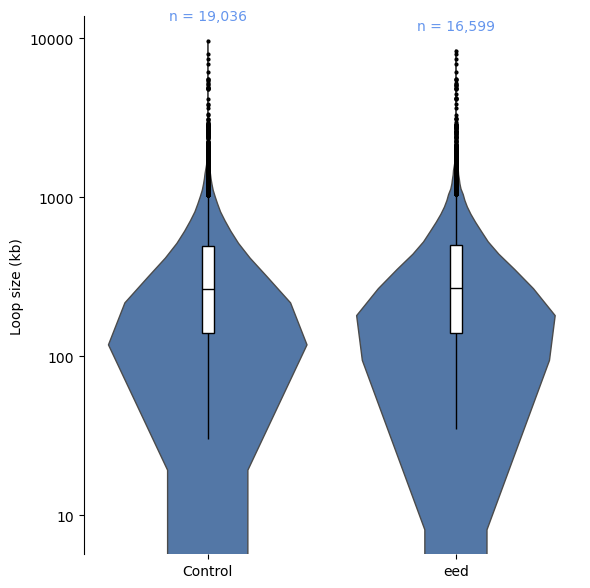

In [8]:
import matplotlib.ticker as ticker
# Plot
plt.figure(figsize=(6, 6))
ax = sns.violinplot(
    data=combined_df,
    x="sample",
    y="loop_size_kb",
    inner=None,
    scale="width",
    linewidth=1,
    color = "#4575b4"
)

sns.boxplot(
    data=combined_df,
    x="sample",
    y="loop_size_kb",
    width=0.05,
    showcaps=False,
    boxprops={'facecolor': 'white', 'edgecolor': 'black', 'linewidth': 1},
    whiskerprops={'color': 'black', 'linewidth': 1},
    medianprops={'color': 'black', 'linewidth': 1},
    flierprops={'marker': 'o', 'markerfacecolor': 'black', 'markeredgecolor': 'black', 'markersize': 2},
    showfliers=True
)

# Style: log scale with plain ticks
ax.set_yscale("log")
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(ticker.NullFormatter())
ax.yaxis.set_minor_locator(ticker.NullLocator())
ax.set_ylabel("Loop size (kb)")
ax.set_xlabel("")
ax.set_title("")

# Add n count at center (median y-position)
for i, label in enumerate(combined_df["sample"].unique()):
    subset = combined_df[combined_df["sample"] == label]
    n = subset.shape[0]
    ymax = subset["loop_size_kb"].max()
    ax.text(i, ymax * 1.3, f"n = {n:,}", ha='center', va='bottom', fontsize=10, color='cornflowerblue')

# Remove top/right/bottom spines
for spine in ['top', 'right', 'bottom']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

In [9]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(ctrl_df['loop_size_kb'], rbp1_df['loop_size_kb'], alternative='two-sided')
print(f"U statistic = {stat:.2e}, p-value = {p:.2e}")

U statistic = 1.55e+08, p-value = 8.20e-03


/tmp/ipykernel_2156403/1788949620.py:4: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


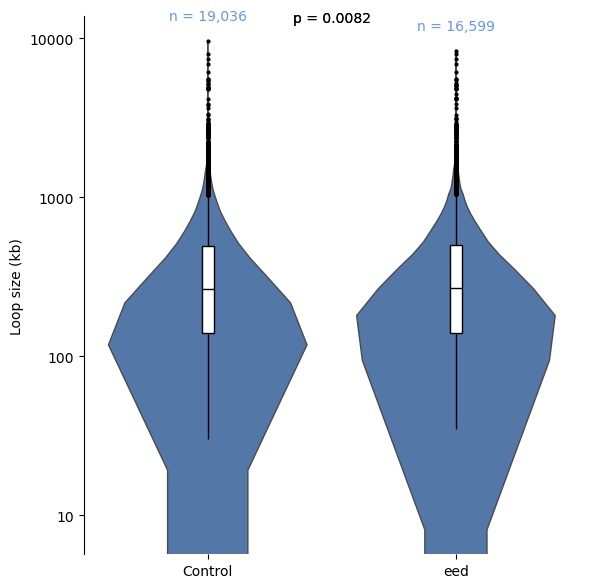

In [10]:
import matplotlib.ticker as ticker
# Plot
plt.figure(figsize=(6, 6))
ax = sns.violinplot(
    data=combined_df,
    x="sample",
    y="loop_size_kb",
    inner=None,
    scale="width",
    linewidth=1,
    color = "#4575b4"
)

sns.boxplot(
    data=combined_df,
    x="sample",
    y="loop_size_kb",
    width=0.05,
    showcaps=False,
    boxprops={'facecolor': 'white', 'edgecolor': 'black', 'linewidth': 1},
    whiskerprops={'color': 'black', 'linewidth': 1},
    medianprops={'color': 'black', 'linewidth': 1},
    flierprops={'marker': 'o', 'markerfacecolor': 'black', 'markeredgecolor': 'black', 'markersize': 2},
    showfliers=True
)

# Style: log scale with plain ticks
ax.set_yscale("log")
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(ticker.NullFormatter())
ax.yaxis.set_minor_locator(ticker.NullLocator())
ax.set_ylabel("Loop size (kb)")
ax.set_xlabel("")
ax.set_title("")

# Add n count at center (median y-position)
for i, label in enumerate(combined_df["sample"].unique()):
    subset = combined_df[combined_df["sample"] == label]
    n = subset.shape[0]
    ymax = subset["loop_size_kb"].max()
    ax.text(i, ymax * 1.3, f"n = {n:,}", ha='center', va='bottom', fontsize=10, color='cornflowerblue')
    ax.text(0.5, 12000, f"p = {p:.4f}", ha='center', va='bottom', fontsize=10)


# Remove top/right/bottom spines
for spine in ['top', 'right', 'bottom']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

In [11]:
def load_bedpe(filepath, label):
    df = pd.read_csv(filepath, sep="\t", header=None, usecols=[1, 2, 4, 5])
    df.columns = ['start1', 'end1', 'start2', 'end2']
    df['loop_size_kb'] = abs(((df['start1'] + df['end1']) // 2) - ((df['start2'] + df['end2']) // 2)) / 1000
    df['sample'] = label
    return df[['loop_size_kb', 'sample']]

In [12]:
# Load datasets
ctrl_df = load_bedpe_and_compute_size("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/megalooplist/mega_merged_loops_ctrl.bedpe", "Merged_Control")
rbp1_df = load_bedpe_and_compute_size("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/megalooplist/mega_merged_loops_rbp1.bedpe", "Merged_eed")

ctcf_ctrl = load_bedpe(
    "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/ctcf_associated_loops_eitheranchoroverlap_ctrl.bedpe",
    "CTCF_Control"
)
ctcf_rbp1 = load_bedpe(
    "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/ctcf_associated_loops_eitheranchoroverlap_rbp1.bedpe",
    "CTCF_eed"
)
h3k27_ctrl = load_bedpe(
    "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/h3k27me3_associated_loops_eitheranchoroverlap_ctrl.bedpe",
    "H3K27me3_Control"
)
h3k27_rbp1 = load_bedpe(
    "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/h3k27me3_associated_loops_eitheranchoroverlap_rbp1.bedpe",
    "H3K27me3_eed"
)

# CTCF loop stats

In [13]:
ctcf_ctrl.describe()

,loop_size_kb
count,3360.000000
mean,278.654762
std,250.699658
min,30.000000
25%,110.000000
50%,200.000000
75%,360.000000
max,2790.000000


In [14]:
ctcf_rbp1.describe()

,loop_size_kb
count,2151.000000
mean,277.821943
std,245.175894
min,35.000000
25%,115.000000
50%,205.000000
75%,355.000000
max,2380.000000


# H3K27me3 loop stats

In [15]:
h3k27_ctrl.describe()

,loop_size_kb
count,1183.000000
mean,411.352494
std,356.397936
min,35.000000
25%,170.000000
50%,305.000000
75%,540.000000
max,2870.000000


In [16]:
h3k27_rbp1.describe()

,loop_size_kb
count,643.000000
mean,399.160187
std,350.302376
min,40.000000
25%,167.500000
50%,290.000000
75%,507.500000
max,2820.000000


In [17]:
combined_df = pd.concat([ctrl_df, rbp1_df, ctcf_ctrl, ctcf_rbp1, h3k27_ctrl, h3k27_rbp1])

/tmp/ipykernel_2156403/3671550269.py:4: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


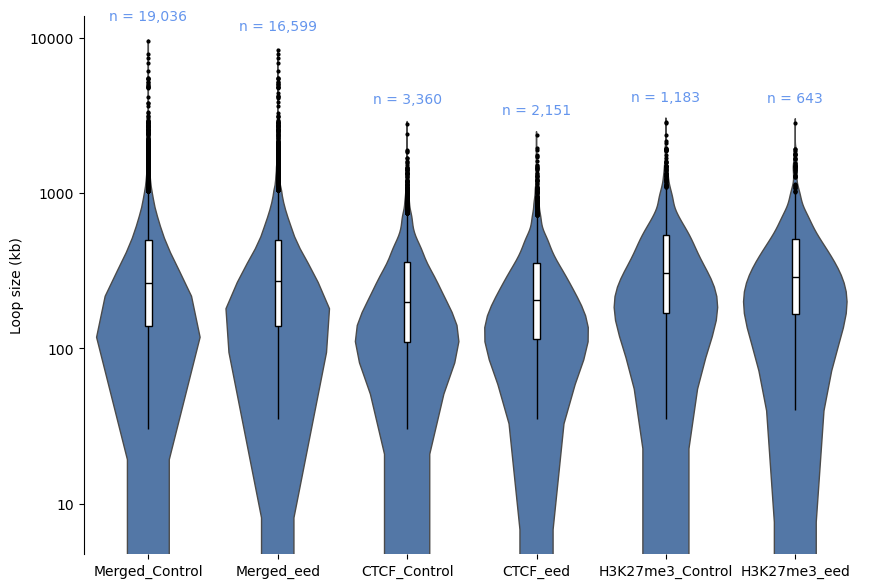

In [18]:
import matplotlib.ticker as ticker
# Plot
plt.figure(figsize=(8.8, 6))
ax = sns.violinplot(
    data=combined_df,
    x="sample",
    y="loop_size_kb",
    inner=None,
    scale="width",
    linewidth=1,
    color = "#4575b4"
)

sns.boxplot(
    data=combined_df,
    x="sample",
    y="loop_size_kb",
    width=0.05,
    showcaps=False,
    boxprops={'facecolor': 'white', 'edgecolor': 'black', 'linewidth': 1},
    whiskerprops={'color': 'black', 'linewidth': 1},
    medianprops={'color': 'black', 'linewidth': 1},
    flierprops={'marker': 'o', 'markerfacecolor': 'black', 'markeredgecolor': 'black', 'markersize': 2},
    showfliers=True
)

# Style: log scale with plain ticks
ax.set_yscale("log")
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(ticker.NullFormatter())
ax.yaxis.set_minor_locator(ticker.NullLocator())
ax.set_ylabel("Loop size (kb)")
ax.set_xlabel("")
ax.set_title("")

# Add n count at center (median y-position)
for i, label in enumerate(combined_df["sample"].unique()):
    subset = combined_df[combined_df["sample"] == label]
    n = subset.shape[0]
    ymax = subset["loop_size_kb"].max()
    ax.text(i, ymax * 1.3, f"n = {n:,}", ha='center', va='bottom', fontsize=10, color='cornflowerblue')

# Remove top/right/bottom spines
for spine in ['top', 'right', 'bottom']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

## H3K27me3 loops tend to be smaller in number, but shifted to slightly longer sizes.

## CTCF-associated loops are denser, but have less extreme long-range tails.

In [19]:
# Kruskal wallis test

In [20]:
#testing
#combined_df = combined_df[combined_df["loop_size_kb"] >= 20]

/tmp/ipykernel_2156403/3096219859.py:4: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/tmp/ipykernel_2156403/3096219859.py:4: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.5`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  ax = sns.violinplot(


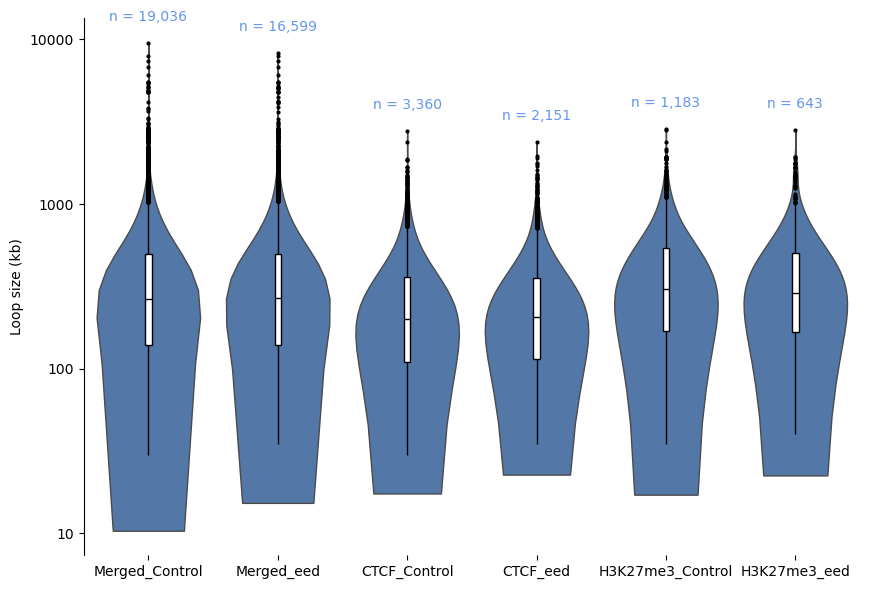

In [22]:
import matplotlib.ticker as ticker
# Plot
plt.figure(figsize=(8.8, 6))
ax = sns.violinplot(
    data=combined_df,
    x="sample",
    y="loop_size_kb",
    inner=None,
    scale="width",
    linewidth=1,
    cut=0.1,
    color = "#4575b4",
    bw=0.5  
)

sns.boxplot(
    data=combined_df,
    x="sample",
    y="loop_size_kb",
    width=0.05,
    showcaps=False,
    boxprops={'facecolor': 'white', 'edgecolor': 'black', 'linewidth': 1},
    whiskerprops={'color': 'black', 'linewidth': 1},
    medianprops={'color': 'black', 'linewidth': 1},
    flierprops={'marker': 'o', 'markerfacecolor': 'black', 'markeredgecolor': 'black', 'markersize': 2},
    showfliers=True
)

# Style: log scale with plain ticks
ax.set_yscale("log")
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(ticker.NullFormatter())
ax.yaxis.set_minor_locator(ticker.NullLocator())
ax.set_ylabel("Loop size (kb)")
ax.set_xlabel("")
ax.set_title("")

# Add n count at center (median y-position)
for i, label in enumerate(combined_df["sample"].unique()):
    subset = combined_df[combined_df["sample"] == label]
    n = subset.shape[0]
    ymax = subset["loop_size_kb"].max()
    ax.text(i, ymax * 1.3, f"n = {n:,}", ha='center', va='bottom', fontsize=10, color='cornflowerblue')

# Remove top/right/bottom spines
for spine in ['top', 'right', 'bottom']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

In [23]:
print(combined_df['loop_size_kb'].describe())

count    42972.000000
mean       370.587359
std        377.704269
min         30.000000
25%        135.000000
50%        260.000000
75%        480.000000
max       9570.000000
Name: loop_size_kb, dtype: float64
